# Correlation Between Human Activity and Pollutants

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine, text
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings(
    'ignore',
    message='invalid value encountered in divide',
    category=RuntimeWarning,
    module=r'mlxtend\.frequent_patterns\.association_rules'
)

DB_USER = 'admin'
DB_PASS = 'admin'
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'pap'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    future=True
)

MILAN_ID = 15146  # ISTAT municipality code for Milano

TARGET_POLLUTANTS = [
    'Biossido di Azoto',
    'PM10 (SM2005)',
    'Particelle sospese PM2.5',
    'Ozono',
]

ALIASES_POLL = {
    'Biossido di Azoto': 'no2',
    'PM10 (SM2005)': 'pm10',
    'Particelle sospese PM2.5': 'pm25',
    'Ozono': 'o3',
}

POLLUTANTS = list(ALIASES_POLL.values())

def per_munic_lmh_bins(df, col, group_col='municipality_id'):
    """Assign LOW/MID/HIGH based on per-municipality tertiles (33rd and 67th percentile)."""
    def _bin_group(s):
        s_valid = s.dropna()
        if len(s_valid) < 3:
            return pd.Series(np.nan, index=s.index)
        p33 = np.nanpercentile(s_valid, 100 / 3)
        p67 = np.nanpercentile(s_valid, 200 / 3)
        eps = max(1e-12, 1e-9 * (s_valid.max() - s_valid.min() + 1.0))
        if p67 <= p33:
            p67 = p33 + eps

        def _to_lmh(v):
            if pd.isna(v):
                return np.nan
            if v <= p33:
                return 'LOW'
            elif v <= p67:
                return 'MID'
            else:
                return 'HIGH'

        return s.apply(_to_lmh)

    return df.groupby(group_col)[col].transform(_bin_group)

def global_lmh_bins(series):
    """Assign LOW/MID/HIGH based on global tertiles (33rd and 67th percentile)."""
    s_valid = series.dropna()
    if len(s_valid) < 3:
        return pd.Series(np.nan, index=series.index)
    p33 = np.nanpercentile(s_valid, 100 / 3)
    p67 = np.nanpercentile(s_valid, 200 / 3)
    eps = max(1e-12, 1e-9 * (s_valid.max() - s_valid.min() + 1.0))
    if p67 <= p33:
        p67 = p33 + eps

    def _to_lmh(v):
        if pd.isna(v):
            return np.nan
        if v <= p33:
            return 'LOW'
        elif v <= p67:
            return 'MID'
        else:
            return 'HIGH'

    return series.apply(_to_lmh)

def slugify(s):
    return re.sub(r'[^A-Z0-9]+', '_', str(s).upper()).strip('_')

def sort_rules(df):
    if df.empty:
        return df
    return df.sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)

def first_item(items):
    return next(iter(items))

def safe_association_rules(freq_items, n_transactions, min_conf):
    if freq_items.empty:
        return pd.DataFrame()
    return association_rules(
        freq_items,
        num_itemsets=n_transactions,
        metric='confidence',
        min_threshold=min_conf
    )

def plot_rules_charts(rules_df, title_prefix, hist_color='steelblue', save_dir=None, save_prefix=None):
    if rules_df.empty:
        print(f'No rules available for charts: {title_prefix}.')
        return

    plt.figure(figsize=(8, 5))
    sc = plt.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap='RdYlGn',
        s=45,
        alpha=0.72
    )
    plt.colorbar(sc, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title(f'{title_prefix}: Support vs Confidence')
    plt.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Conf = 0.5')
    plt.legend(fontsize=8)
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_support_confidence.png'), dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(rules_df['lift'], bins=30, color=hist_color, alpha=0.82, edgecolor='white')
    plt.axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (no association)')
    plt.xlabel('Lift')
    plt.ylabel('Number of rules')
    plt.title(f'Lift distribution ({title_prefix})')
    plt.legend()
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_lift_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(
        f"{title_prefix} | Lift min: {rules_df['lift'].min():.2f} "
        f"mean: {rules_df['lift'].mean():.2f} max: {rules_df['lift'].max():.2f}"
    )

def plot_top_rules(rules_df, title, cmap_name='Reds', top_n=14, save_dir=None, save_prefix=None):
    if rules_df.empty:
        print(f'No top rules available for: {title}.')
        return

    top_chart = rules_df.head(top_n).copy()
    plt.figure(figsize=(13, 6))
    colors = plt.get_cmap(cmap_name)(np.linspace(0.4, 0.9, len(top_chart)))
    plt.barh(top_chart['rule'], top_chart['lift'], color=colors[::-1], alpha=0.85)
    plt.gca().invert_yaxis()
    plt.xlabel('Lift')
    plt.axvline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.45)
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_top_rules.png'), dpi=150, bbox_inches='tight')
    plt.show()

IMGS_DIR = os.path.join('..', 'docs', 'images', '4_human_activities')
TABS_DIR = os.path.join('..', 'docs', 'tables', '4_human_activities')
os.makedirs(IMGS_DIR, exist_ok=True)
os.makedirs(TABS_DIR, exist_ok=True)
POLLUTANTS = list(ALIASES_POLL.values())

In [2]:
SQL_POLL_DAILY = """
SELECT
    m.municipality_id,
    m.name AS municipality_name,
    d.date::date AS date,
    se.name AS sensor_name,
    AVG(sf.mean_value) AS value
FROM pap.sample_ft sf
JOIN pap.sensor_dt se ON se.sensor_id = sf.sensor_id
JOIN pap.station_dt st ON st.station_id = se.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = sf.date_id
WHERE d.year = 2023
  AND se.name = ANY(:wanted)
  AND m.municipality_id = :milan_id
GROUP BY m.municipality_id, m.name, d.date, se.name
ORDER BY m.municipality_id, d.date, se.name;
"""

SQL_TRAFFIC_DAILY = """
SELECT
    d.date::date AS date,
    SUM(ga.count) AS traffic_accesses
FROM pap.gate_access_ft ga
JOIN pap.date_dt d ON d.date_id = ga.date_id
WHERE d.year = 2023
GROUP BY d.date
ORDER BY d.date;
"""

with engine.connect() as con:
    poll_long = pd.read_sql(text(SQL_POLL_DAILY), con, params={'wanted': TARGET_POLLUTANTS, 'milan_id': MILAN_ID})
    traffic_daily = pd.read_sql(text(SQL_TRAFFIC_DAILY), con)

poll_long['date'] = pd.to_datetime(poll_long['date'])
traffic_daily['date'] = pd.to_datetime(traffic_daily['date'])
poll_long['pollutant'] = poll_long['sensor_name'].map(ALIASES_POLL)

poll_wide = poll_long.pivot_table(
    index=['municipality_id', 'municipality_name', 'date'],
    columns='pollutant',
    values='value',
    aggfunc='mean'
).reset_index()

for p in POLLUTANTS:
    if p not in poll_wide.columns:
        poll_wide[p] = np.nan

daily_df = pd.merge(
    poll_wide,
    traffic_daily,
    on='date',
    how='inner'
).sort_values(['municipality_id', 'date']).reset_index(drop=True)

print(f'Merged rows (municipality × day): {len(daily_df):,}')
print(f'Municipalities: {daily_df["municipality_id"].nunique()}')
print(f'Period: {daily_df["date"].min().date()} -> {daily_df["date"].max().date()}')
display(daily_df.head())


Merged rows (municipality × day): 351
Municipalities: 1
Period: 2023-01-01 -> 2023-12-31


,municipality_id,municipality_name,date,no2,o3,pm10,pm25,traffic_accesses
0,15146,Milano,2023-01-01,29.1816,1.7750,57.05,54.333333,55678
1,15146,Milano,2023-01-02,33.4284,1.5040,25.30,24.000000,61954
2,15146,Milano,2023-01-03,32.7984,1.2815,15.95,15.000000,70620
3,15146,Milano,2023-01-04,34.3974,3.9875,26.65,22.333333,77677
4,15146,Milano,2023-01-05,35.4924,8.6960,29.60,23.666667,86787


## TRAFFIC -> POLLUTANTS

In [3]:
df_rules_daily = daily_df.copy()

df_rules_daily['traffic_bin'] = global_lmh_bins(df_rules_daily['traffic_accesses'])

for p in POLLUTANTS:
    df_rules_daily[f'{p}_bin'] = per_munic_lmh_bins(df_rules_daily, p)

basket = pd.DataFrame(index=df_rules_daily.index)
traffic_items = []
poll_items = []

for lab in ['LOW', 'MID', 'HIGH']:
    col = f'TRAFFIC_{lab}'
    basket[col] = (df_rules_daily['traffic_bin'] == lab)
    traffic_items.append(col)

for p in POLLUTANTS:
    pref = p.upper()
    for lab in ['LOW', 'MID', 'HIGH']:
        col = f'{pref}_{lab}'
        basket[col] = (df_rules_daily[f'{p}_bin'] == lab)
        poll_items.append(col)

basket = basket.fillna(False).astype(bool)

print(f'Daily transactions: {basket.shape[0]:,}')
print(f'Numero item: {basket.shape[1]}')
print(f'Traffic items: {len(traffic_items)} | Pollutant items: {len(poll_items)}')
item_freq = basket.mean().sort_values(ascending=False)
print(f'Top-10 frequent items:\n{item_freq.head(10).to_string()}')
display(basket.head())

Daily transactions: 351
Numero item: 15
Traffic items: 3 | Pollutant items: 12
Top-10 frequent items:
PM25_LOW        0.344729
TRAFFIC_MID     0.333333
TRAFFIC_LOW     0.333333
NO2_LOW         0.333333
NO2_MID         0.333333
NO2_HIGH        0.333333
TRAFFIC_HIGH    0.333333
PM10_LOW        0.333333
PM10_MID        0.333333
PM10_HIGH       0.333333


,TRAFFIC_LOW,TRAFFIC_MID,TRAFFIC_HIGH,NO2_LOW,NO2_MID,NO2_HIGH,PM10_LOW,PM10_MID,PM10_HIGH,PM25_LOW,PM25_MID,PM25_HIGH,O3_LOW,O3_MID,O3_HIGH
0,True,False,False,False,True,False,False,False,True,False,False,True,True,False,False
1,True,False,False,False,True,False,False,True,False,False,False,True,True,False,False
2,True,False,False,False,True,False,True,False,False,False,True,False,True,False,False
3,True,False,False,False,True,False,False,True,False,False,False,True,True,False,False
4,True,False,False,False,True,False,False,False,True,False,False,True,True,False,False


Frequent itemsets: 600
Rules TRAFFIC -> POLLUTANTS (combinations) before thresholds: 74
Rules TRAFFIC -> POLLUTANTS (combinations): 53
Rules TRAFFIC -> PARTICULATE (combinations): 41
Daily rules TRAFFIC -> POLLUTANT combinations


,antecedent,consequent,support,confidence,lift
0,TRAFFIC_LOW,NO2_LOW + O3_HIGH + PM10_LOW,0.082621,0.247863,1.891304
1,TRAFFIC_LOW,NO2_LOW + O3_HIGH,0.156695,0.470085,1.833333
2,TRAFFIC_LOW,NO2_LOW + O3_HIGH + PM25_MID,0.079772,0.239316,1.826087
3,TRAFFIC_LOW,NO2_LOW + PM25_MID,0.088319,0.264957,1.823529
4,TRAFFIC_LOW,NO2_LOW + O3_HIGH + PM25_LOW,0.074074,0.222222,1.813953
5,TRAFFIC_LOW,O3_HIGH + PM10_LOW + PM25_LOW,0.068376,0.205128,1.800000
6,TRAFFIC_LOW,O3_HIGH + PM10_LOW,0.085470,0.256410,1.800000
7,TRAFFIC_LOW,NO2_LOW + PM10_LOW,0.113960,0.341880,1.791045
8,TRAFFIC_LOW,NO2_LOW + PM10_LOW + PM25_LOW,0.094017,0.282051,1.767857
9,TRAFFIC_LOW,NO2_LOW,0.193732,0.581197,1.743590


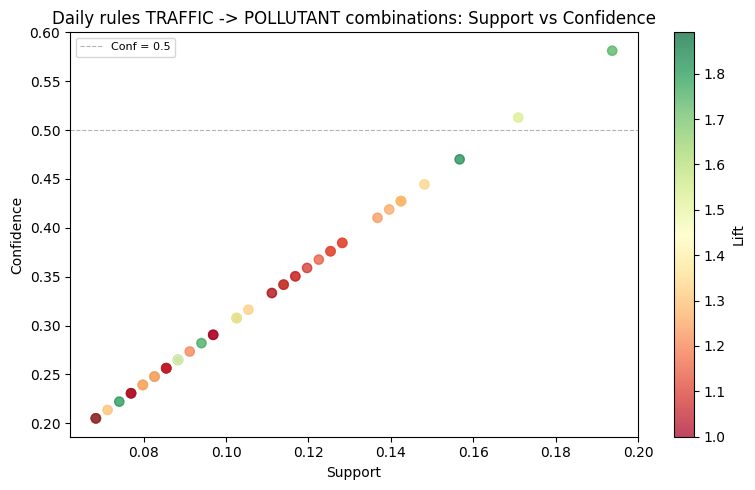

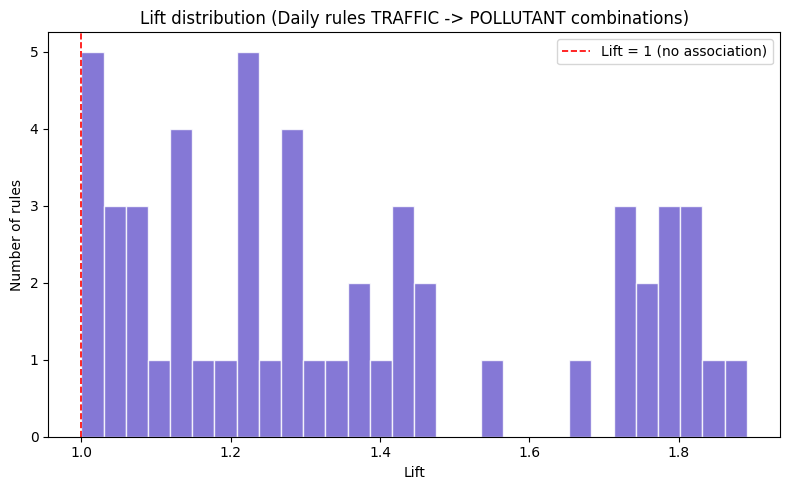

Daily rules TRAFFIC -> POLLUTANT combinations | Lift min: 1.00 mean: 1.37 max: 1.89


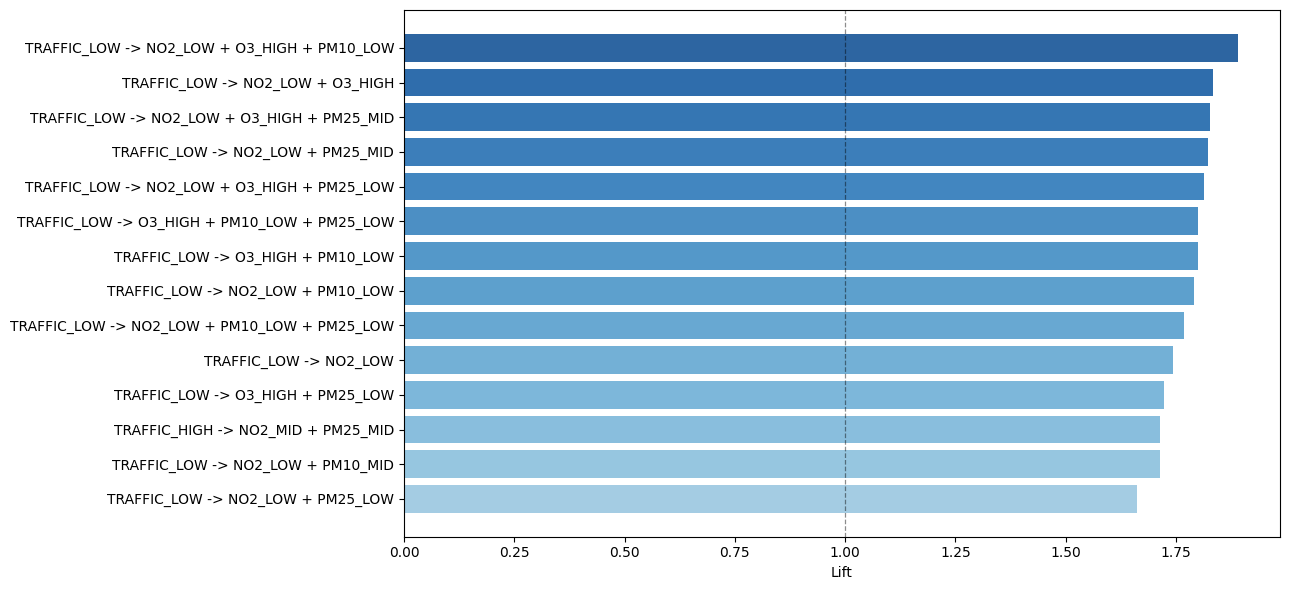

In [4]:
MIN_SUPPORT = 0.005
MIN_CONF = 0.20
MIN_LIFT = 1.00
MIN_RULE_SUPPORT = 0.005
MAX_LEN = 18

freq_items = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True
).sort_values('support', ascending=False).reset_index(drop=True)

rules_all = safe_association_rules(freq_items, len(basket), MIN_CONF)

traffic_set = set(traffic_items)
poll_set = set(poll_items)

def set_to_text(items):
    return ' + '.join(sorted(items))

def is_traffic_to_poll_combo(ant, con):
    ant = set(ant)
    con = set(con)
    return (
        len(ant) > 0
        and ant.issubset(traffic_set)
        and len(con) > 0
        and con.issubset(poll_set)
    )

mask = rules_all.apply(lambda r: is_traffic_to_poll_combo(r['antecedents'], r['consequents']), axis=1)
pollutant_rules = rules_all[mask].copy()

pollutant_rules['antecedent'] = pollutant_rules['antecedents'].apply(set_to_text)
pollutant_rules['consequent'] = pollutant_rules['consequents'].apply(set_to_text)
pollutant_rules['n_antecedents'] = pollutant_rules['antecedents'].apply(len)
pollutant_rules['n_consequents'] = pollutant_rules['consequents'].apply(len)
pollutant_rules['rule'] = (
    pollutant_rules['antecedent']
    + ' -> '
    + pollutant_rules['consequent']
)

pollutant_rules = sort_rules(pollutant_rules)
base_count = len(pollutant_rules)
pollutant_rules = pollutant_rules[
    (pollutant_rules['lift'] >= MIN_LIFT)
    & (pollutant_rules['support'] >= MIN_RULE_SUPPORT)
].copy()
pollutant_rules = sort_rules(pollutant_rules)

particulate_rules = pollutant_rules[
    pollutant_rules['consequents'].apply(lambda cs: any(i.startswith(('PM10_', 'PM25_')) for i in cs))
].copy()
particulate_rules = sort_rules(particulate_rules)

print(f'Frequent itemsets: {len(freq_items):,}')
print(f'Rules TRAFFIC -> POLLUTANTS (combinations) before thresholds: {base_count:,}')
print(f'Rules TRAFFIC -> POLLUTANTS (combinations): {len(pollutant_rules):,}')
print(f'Rules TRAFFIC -> PARTICULATE (combinations): {len(particulate_rules):,}')

print('Daily rules TRAFFIC -> POLLUTANT combinations')
display(pollutant_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']])
pollutant_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].to_csv(
    os.path.join(TABS_DIR, 'daily_traffic_pollutant_rules.csv'), index=False
)
plot_rules_charts(pollutant_rules, 'Daily rules TRAFFIC -> POLLUTANT combinations', hist_color='slateblue',
                  save_dir=IMGS_DIR, save_prefix='daily_traffic_rules')
plot_top_rules(pollutant_rules, 'TRAFFIC -> POLLUTANT combinations (daily)', cmap_name='Blues', top_n=14,
               save_dir=IMGS_DIR, save_prefix='daily_traffic_rules')


## TOURISM -> POLLUTANTS

In [5]:
YEAR_FILTER = 2023

SQL_POLL_MONTHLY_MUNI = """
SELECT
    m.municipality_id,
    m.name AS municipality_name,
    d.year,
    d.month,
    se.name AS sensor_name,
    AVG(sf.mean_value) AS value
FROM pap.sample_ft sf
JOIN pap.sensor_dt se ON se.sensor_id = sf.sensor_id
JOIN pap.station_dt st ON st.station_id = se.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = sf.date_id
WHERE d.year = :year
  AND se.name = ANY(:wanted)
GROUP BY m.municipality_id, m.name, d.year, d.month, se.name
ORDER BY m.municipality_id, d.year, d.month, se.name;
"""

SQL_TOURISM_MONTHLY = """
SELECT
    o.municipality_id,
    md.year,
    md.month,
    SUM(o.count)::double precision AS overnights
FROM pap.overnights_ft o
JOIN pap.month_dt md ON md.month_id = o.month_id
WHERE md.year = :year
GROUP BY o.municipality_id, md.year, md.month
ORDER BY o.municipality_id, md.year, md.month;
"""

SQL_POP_YEARLY = """
SELECT
    p.municipality_id,
    d.year,
    AVG(p.population)::double precision AS population
FROM pap.population_dt p
JOIN pap.date_dt d ON d.date_id = p.date_id
WHERE d.year = :year
GROUP BY p.municipality_id, d.year
ORDER BY p.municipality_id, d.year;
"""

with engine.connect() as con:
    poll_month_long = pd.read_sql(
        text(SQL_POLL_MONTHLY_MUNI),
        con,
        params={"year": YEAR_FILTER, "wanted": TARGET_POLLUTANTS}
    )
    tourism_month = pd.read_sql(
        text(SQL_TOURISM_MONTHLY),
        con,
        params={"year": YEAR_FILTER}
    )
    pop_year = pd.read_sql(
        text(SQL_POP_YEARLY),
        con,
        params={"year": YEAR_FILTER}
    )

poll_month_long["pollutant"] = poll_month_long["sensor_name"].map(ALIASES_POLL)

poll_month_wide = (
    poll_month_long
    .pivot_table(
        index=["municipality_id", "municipality_name", "year", "month"],
        columns="pollutant",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

for p in POLLUTANTS:
    if p not in poll_month_wide.columns:
        poll_month_wide[p] = np.nan

tourism_pop = tourism_month.merge(
    pop_year,
    on=["municipality_id", "year"],
    how="inner"
)

tourism_pop = tourism_pop[tourism_pop["population"] > 0].copy()
# Required tourism index: tourism/population ratio
tourism_pop["tourism_index"] = tourism_pop["overnights"] / tourism_pop["population"]

merged_monthly_tp = poll_month_wide.merge(
    tourism_pop[["municipality_id", "year", "month", "overnights", "population", "tourism_index"]],
    on=["municipality_id", "year", "month"],
    how="inner"
).sort_values(["municipality_id", "year", "month"]).reset_index(drop=True)

months_tourism = sorted(tourism_month["month"].dropna().astype(int).unique().tolist())
months_after_tour_pop = sorted(tourism_pop["month"].dropna().astype(int).unique().tolist())
months_final = sorted(merged_monthly_tp["month"].dropna().astype(int).unique().tolist())

print(f"Months in tourism_month: {months_tourism}")
print(f"Months after tourism+population merge: {months_after_tour_pop}")
print(f"Months in final dataset: {months_final}")
print(f"Final municipality-month rows: {len(merged_monthly_tp):,}")
print(f"Covered municipalities: {merged_monthly_tp['municipality_id'].nunique():,}")
display(merged_monthly_tp.head())


Months in tourism_month: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Months after tourism+population merge: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Months in final dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Final municipality-month rows: 582
Covered municipalities: 49


,municipality_id,municipality_name,year,month,no2,o3,pm10,pm25,overnights,population,tourism_index
0,12026,Busto Arsizio,2023,1,17.683290,11.409516,28.000000,NaN,2582.0,83372.0,0.030970
1,12026,Busto Arsizio,2023,2,20.917214,24.118357,36.000000,NaN,2790.0,83372.0,0.033464
2,12026,Busto Arsizio,2023,3,24.299161,39.519742,23.838710,NaN,3113.0,83372.0,0.037339
3,12026,Busto Arsizio,2023,4,19.565067,52.451533,13.607143,NaN,3686.0,83372.0,0.044211
4,12026,Busto Arsizio,2023,5,13.554032,57.180484,10.838710,NaN,4411.0,83372.0,0.052907


In [6]:
df_rules_tp = merged_monthly_tp.copy()

# Bin tourism by per-municipality overnights tertiles (LOW/MID/HIGH within each municipality's annual distribution)
df_rules_tp['tourism_bin'] = per_munic_lmh_bins(df_rules_tp, 'overnights')

print('TOURISM class distribution (monthly, per-municipality overnights tertiles):')
print(df_rules_tp['tourism_bin'].value_counts(normalize=True, dropna=False).round(4).to_string())

for p in POLLUTANTS:
    df_rules_tp[f"{p}_bin"] = per_munic_lmh_bins(df_rules_tp, p)

basket_tp = pd.DataFrame(index=df_rules_tp.index)
tourism_items = []
poll_items_tp = []

for lab in ["LOW", "MID", "HIGH"]:
    col = f"TOURISM_{lab}"
    basket_tp[col] = (df_rules_tp["tourism_bin"] == lab)
    tourism_items.append(col)

for p in POLLUTANTS:
    pref = p.upper()
    for lab in ["LOW", "MID", "HIGH"]:
        col = f"{pref}_{lab}"
        basket_tp[col] = (df_rules_tp[f"{p}_bin"] == lab)
        poll_items_tp.append(col)

basket_tp = basket_tp.fillna(False).astype(bool)

print(f"Municipality-month transactions: {basket_tp.shape[0]:,}")
print(f"Numero item: {basket_tp.shape[1]}")
print(f"Tourism items: {len(tourism_items)} | Pollutant items: {len(poll_items_tp)}")
item_freq_tp = basket_tp.mean().sort_values(ascending=False)
print(f"Frequent items:\n{item_freq_tp.to_string()}")
display(basket_tp.head())


TOURISM class distribution (monthly, per-municipality overnights tertiles):
tourism_bin
LOW     0.3351
HIGH    0.3333
MID     0.3316
Municipality-month transactions: 582
Numero item: 15
Tourism items: 3 | Pollutant items: 12
Frequent items:
TOURISM_LOW     0.335052
NO2_LOW         0.335052
TOURISM_HIGH    0.333333
NO2_HIGH        0.333333
TOURISM_MID     0.331615
NO2_MID         0.331615
PM10_LOW        0.259450
PM10_HIGH       0.257732
PM10_MID        0.256014
O3_LOW          0.231959
O3_HIGH         0.226804
O3_MID          0.225086
PM25_LOW        0.142612
PM25_HIGH       0.140893
PM25_MID        0.139175


,TOURISM_LOW,TOURISM_MID,TOURISM_HIGH,NO2_LOW,NO2_MID,NO2_HIGH,PM10_LOW,PM10_MID,PM10_HIGH,PM25_LOW,PM25_MID,PM25_HIGH,O3_LOW,O3_MID,O3_HIGH
0,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False
1,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False
2,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False
3,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False
4,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True


Frequent itemsets: 371
Rules TOURISM -> POLLUTANTS (combinations) before thresholds: 35
Rules TOURISM -> POLLUTANTS (combinations): 32


,antecedent,consequent,n_consequents,support,confidence,lift
0,TOURISM_LOW,O3_LOW + PM10_HIGH + PM25_HIGH,3,0.068729,0.205128,2.652991
1,TOURISM_LOW,NO2_HIGH + PM10_HIGH + PM25_HIGH,3,0.089347,0.266667,2.630508
2,TOURISM_LOW,PM10_HIGH + PM25_HIGH,2,0.099656,0.297436,2.545701
3,TOURISM_LOW,O3_LOW + PM25_HIGH,2,0.072165,0.215385,2.507077
4,TOURISM_LOW,NO2_HIGH + O3_LOW + PM25_HIGH,3,0.068729,0.205128,2.487179
5,TOURISM_LOW,NO2_HIGH + O3_LOW + PM10_HIGH,3,0.104811,0.312821,2.395547
6,TOURISM_LOW,O3_LOW + PM10_HIGH,2,0.111684,0.333333,2.395062
7,TOURISM_LOW,NO2_HIGH + PM25_HIGH,2,0.096220,0.287179,2.387692
8,TOURISM_LOW,NO2_HIGH + PM10_HIGH,2,0.158076,0.471795,2.326988
9,TOURISM_LOW,PM25_HIGH,1,0.108247,0.323077,2.293058


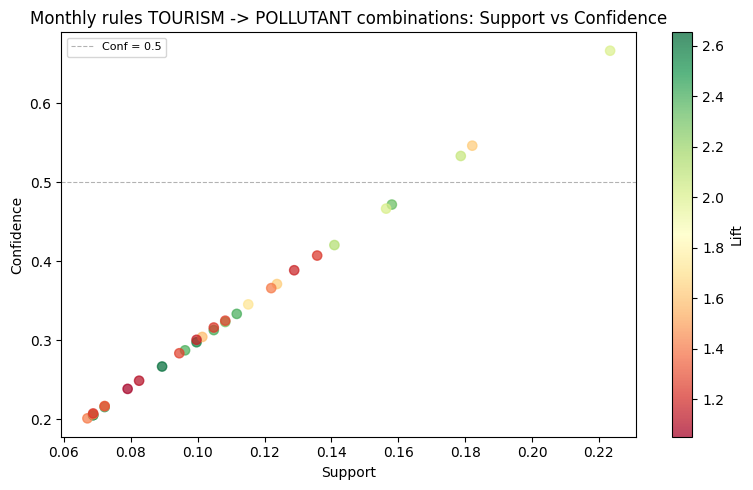

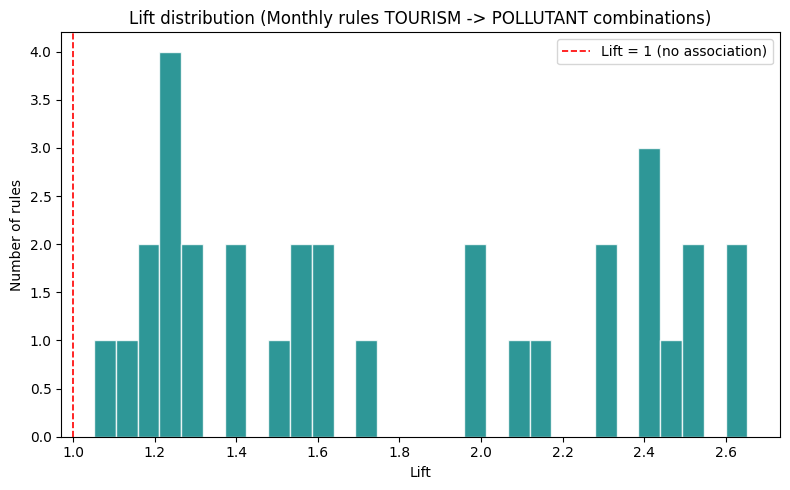

Monthly rules TOURISM -> POLLUTANT combinations | Lift min: 1.05 mean: 1.79 max: 2.65


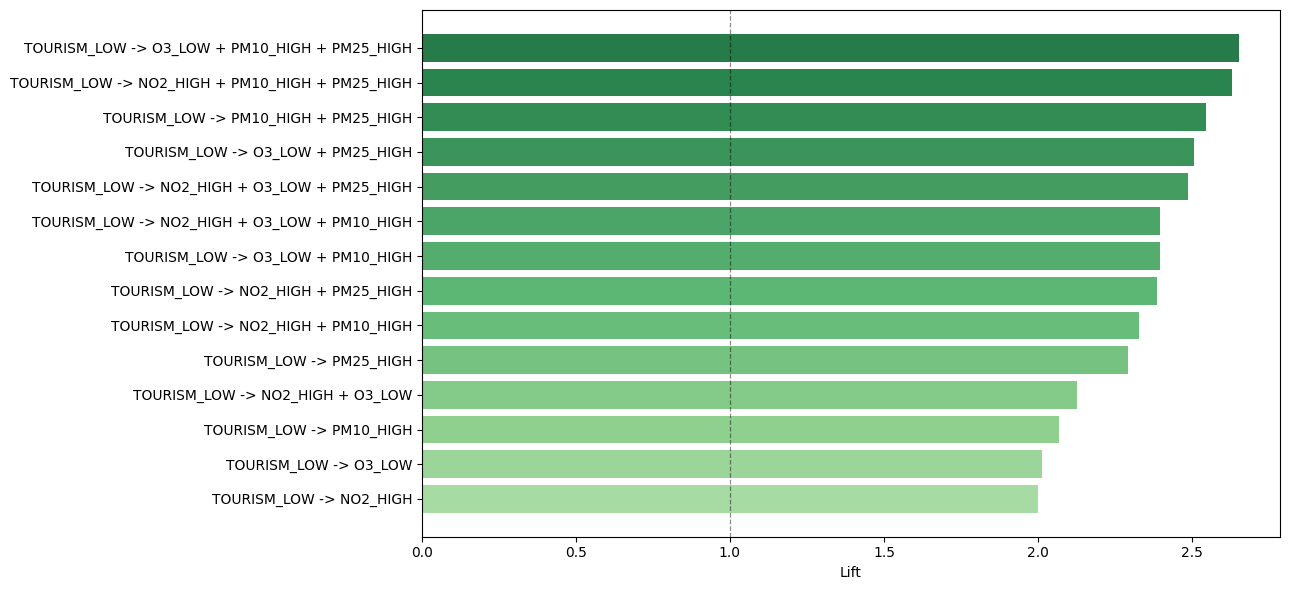

In [7]:
MIN_SUPPORT_TP = 0.005
MIN_CONF_TP = 0.20
MIN_LIFT_TP = 1.00
MIN_RULE_SUPPORT_TP = 0.005
MAX_LEN_TP = 18

freq_tp = apriori(
    basket_tp,
    min_support=MIN_SUPPORT_TP,
    use_colnames=True,
    max_len=MAX_LEN_TP,
    low_memory=True
).sort_values("support", ascending=False).reset_index(drop=True)

rules_all_tp = safe_association_rules(freq_tp, len(basket_tp), MIN_CONF_TP)

tourism_set = set(tourism_items)
poll_set_tp = set(poll_items_tp)

def set_to_text(items):
    return " + ".join(sorted(items))

def is_tourism_to_poll_combo(ant, con):
    ant = set(ant)
    con = set(con)
    return (
        len(ant) > 0
        and ant.issubset(tourism_set)
        and len(con) > 0
        and con.issubset(poll_set_tp)
    )

mask_tp = rules_all_tp.apply(
    lambda r: is_tourism_to_poll_combo(r["antecedents"], r["consequents"]),
    axis=1
)
tourism_pollutant_rules = rules_all_tp[mask_tp].copy()

tourism_pollutant_rules["antecedent"] = tourism_pollutant_rules["antecedents"].apply(set_to_text)
tourism_pollutant_rules["consequent"] = tourism_pollutant_rules["consequents"].apply(set_to_text)
tourism_pollutant_rules["n_antecedents"] = tourism_pollutant_rules["antecedents"].apply(len)
tourism_pollutant_rules["n_consequents"] = tourism_pollutant_rules["consequents"].apply(len)
tourism_pollutant_rules["rule"] = (
    tourism_pollutant_rules["antecedent"]
    + " -> "
    + tourism_pollutant_rules["consequent"]
)

tourism_pollutant_rules = sort_rules(tourism_pollutant_rules)
base_count_tp = len(tourism_pollutant_rules)
tourism_pollutant_rules = tourism_pollutant_rules[
    (tourism_pollutant_rules["lift"] >= MIN_LIFT_TP)
    & (tourism_pollutant_rules["support"] >= MIN_RULE_SUPPORT_TP)
].copy()
tourism_pollutant_rules = sort_rules(tourism_pollutant_rules)

print(f"Frequent itemsets: {len(freq_tp):,}")
print(f"Rules TOURISM -> POLLUTANTS (combinations) before thresholds: {base_count_tp:,}")
print(f"Rules TOURISM -> POLLUTANTS (combinations): {len(tourism_pollutant_rules):,}")

show_cols = ["antecedent", "consequent", "n_consequents", "support", "confidence", "lift"]
display(tourism_pollutant_rules[show_cols])
tourism_pollutant_rules[show_cols].to_csv(
    os.path.join(TABS_DIR, 'monthly_tourism_pollutant_rules.csv'), index=False
)

plot_rules_charts(
    tourism_pollutant_rules,
    "Monthly rules TOURISM -> POLLUTANT combinations",
    hist_color="teal",
    save_dir=IMGS_DIR,
    save_prefix="monthly_tourism_rules"
)
plot_top_rules(
    tourism_pollutant_rules,
    "TOURISM -> POLLUTANT combinations (monthly)",
    cmap_name="Greens",
    top_n=14,
    save_dir=IMGS_DIR,
    save_prefix="monthly_tourism_rules"
)


## Monthly pollutant trend by class

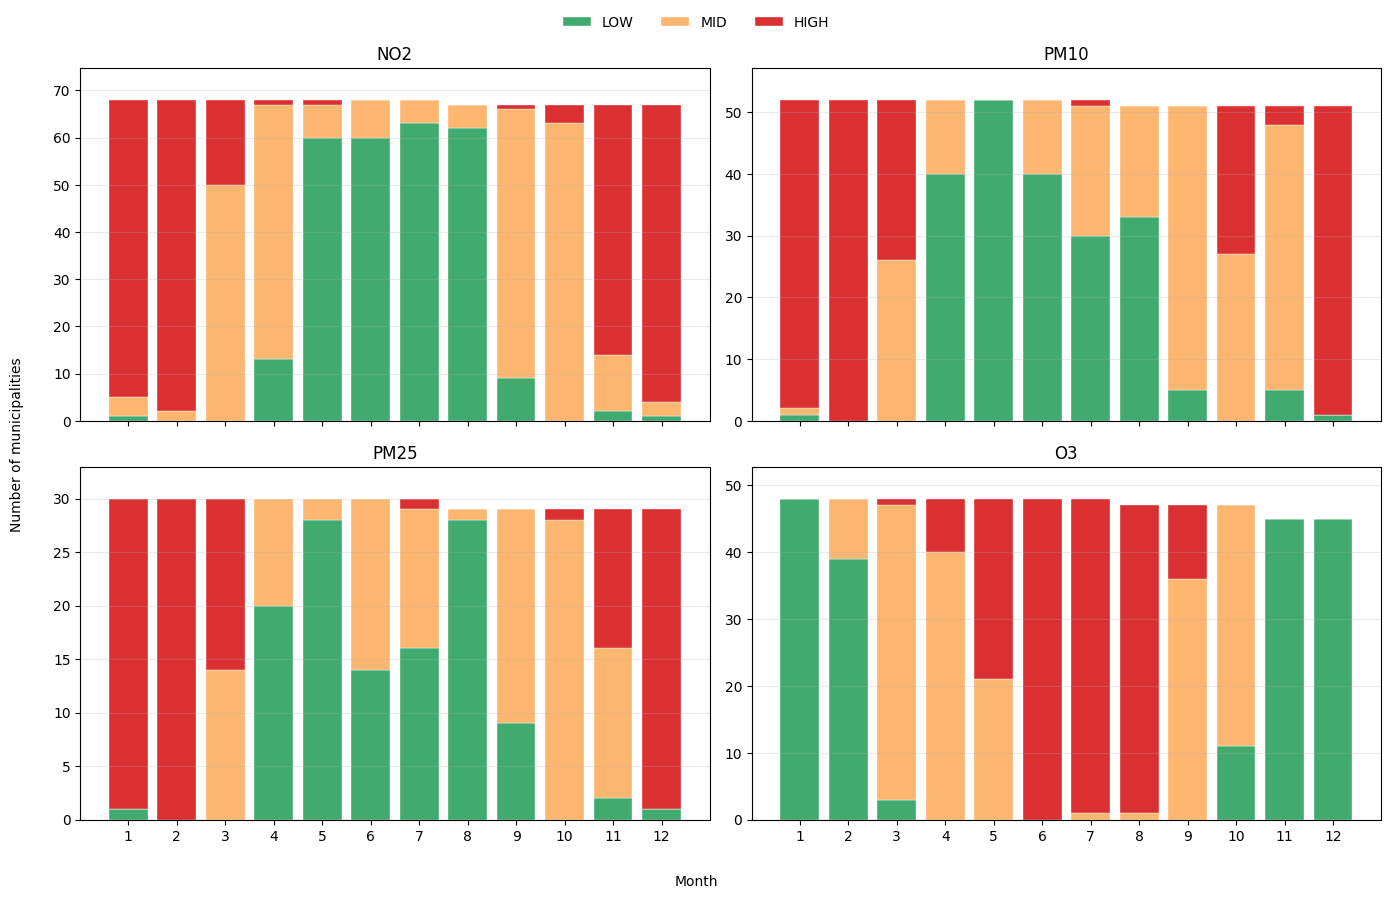

,month,level,count,pollutant
0,1,LOW,1.0,NO2
1,2,LOW,0.0,NO2
2,3,LOW,0.0,NO2
3,4,LOW,13.0,NO2
4,5,LOW,60.0,NO2
5,6,LOW,60.0,NO2
6,7,LOW,63.0,NO2
7,8,LOW,62.0,NO2
8,9,LOW,9.0,NO2
9,10,LOW,0.0,NO2


In [8]:
if 'poll_month_wide' not in globals():
    raise RuntimeError('Run cell 8 first to create poll_month_wide (municipality-month data).')

monthly_plot_df = poll_month_wide.copy()

for p in POLLUTANTS:
    if p not in monthly_plot_df.columns:
        monthly_plot_df[p] = np.nan
    monthly_plot_df[f'{p}_bin'] = per_munic_lmh_bins(monthly_plot_df, p)

plot_levels = ['LOW', 'MID', 'HIGH']
palette = {'LOW': '#2ca25f', 'MID': '#fdae61', 'HIGH': '#d7191c'}

n_cols = 2
n_rows = int(np.ceil(len(POLLUTANTS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.6 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)

distribution_frames = []

for i, p in enumerate(POLLUTANTS):
    ax = axes[i]
    col_bin = f'{p}_bin'

    # Monthly counts of municipalities in LOW/MID/HIGH
    cnt = (
        monthly_plot_df
        .groupby('month')[col_bin]
        .value_counts(normalize=False)
        .rename('count')
        .reset_index()
    )

    pivot = (
        cnt
        .pivot(index='month', columns=col_bin, values='count')
        .reindex(columns=plot_levels)
        .fillna(0)
        .reindex(range(1, 13), fill_value=0)
    )

    month_dist = pivot.reset_index().melt(
        id_vars='month',
        value_vars=plot_levels,
        var_name='level',
        value_name='count'
    )
    month_dist['pollutant'] = p.upper()
    distribution_frames.append(month_dist)

    bottom = np.zeros(len(pivot), dtype=float)
    for lev in plot_levels:
        vals = pivot[lev].to_numpy(dtype=float)
        ax.bar(
            pivot.index,
            vals,
            bottom=bottom,
            width=0.8,
            color=palette[lev],
            alpha=0.9,
            label=lev,
            edgecolor='white',
            linewidth=0.3
        )
        bottom = bottom + vals

    ax.set_title(f'{p.upper()}')
    ax.set_xticks(range(1, 13))
    ax.set_ylim(0, max(1, bottom.max()) * 1.1)
    ax.grid(axis='y', alpha=0.25)

# Hide any empty subplots
for j in range(len(POLLUTANTS), len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))
fig.text(0.5, 0.02, 'Month', ha='center')
fig.text(0.01, 0.5, 'Number of municipalities', va='center', rotation='vertical')
plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])
plt.savefig(os.path.join(IMGS_DIR, 'monthly_pollutant_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

distribution_df = pd.concat(distribution_frames, ignore_index=True)
display(distribution_df.head(15))


## Daily pollutant trend by class (LOW/MID/HIGH)

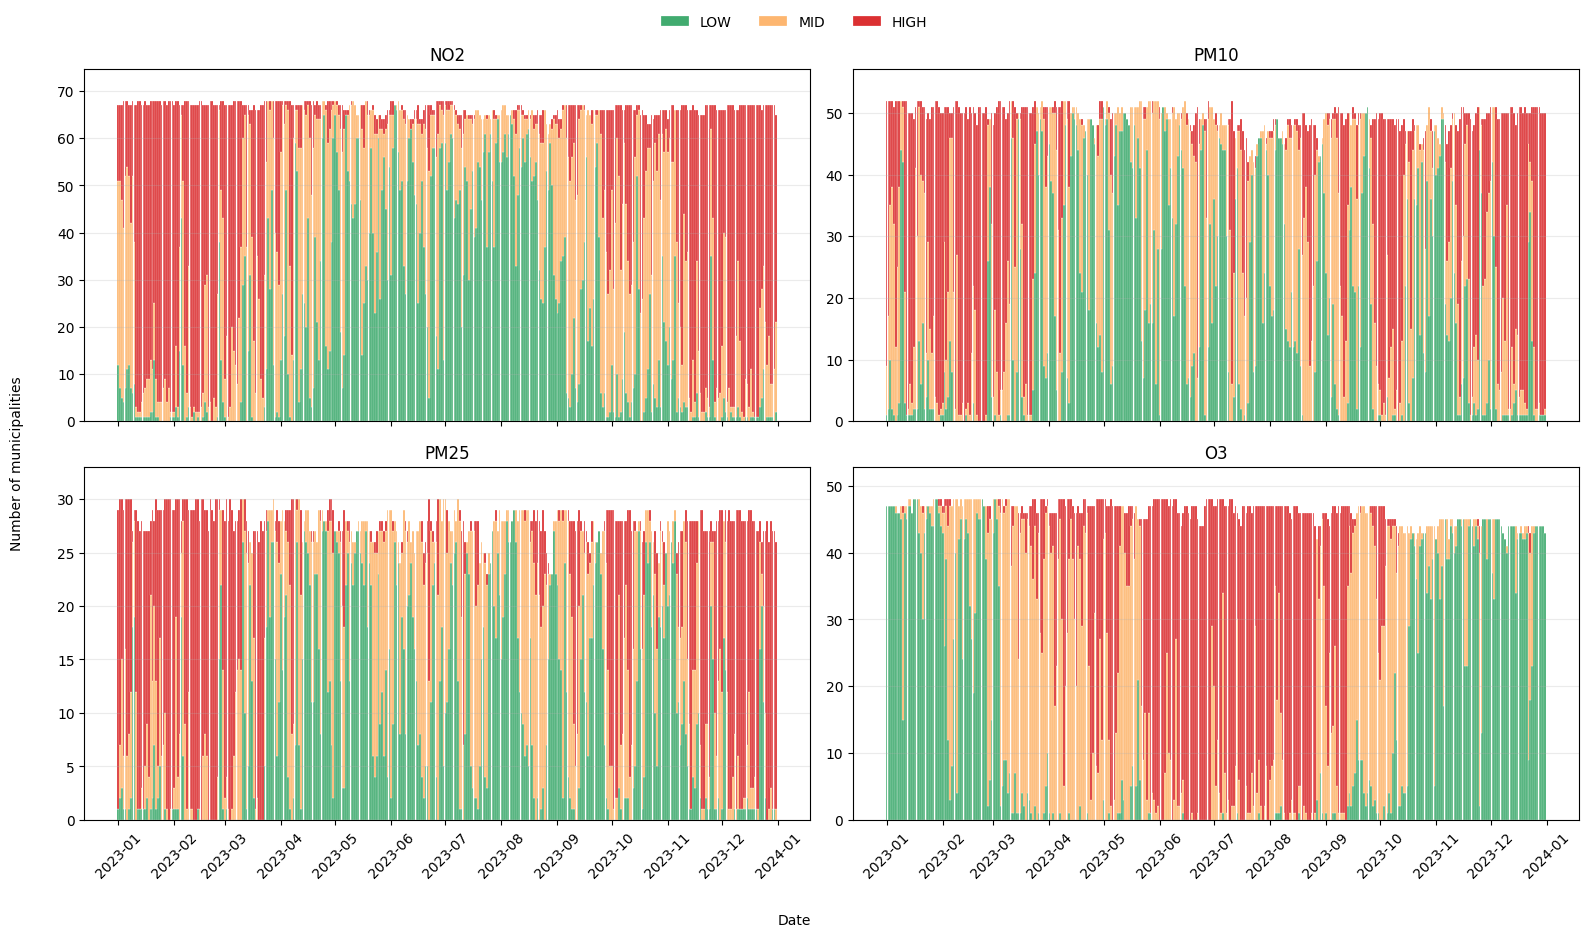

,date,level,count,pollutant
0,2023-01-01,LOW,12.0,NO2
1,2023-01-02,LOW,7.0,NO2
2,2023-01-03,LOW,5.0,NO2
3,2023-01-04,LOW,4.0,NO2
4,2023-01-05,LOW,7.0,NO2
5,2023-01-06,LOW,11.0,NO2
6,2023-01-07,LOW,12.0,NO2
7,2023-01-08,LOW,7.0,NO2
8,2023-01-09,LOW,6.0,NO2
9,2023-01-10,LOW,8.0,NO2


In [9]:

SQL_POLL_DAILY_MUNI = """
SELECT
    m.municipality_id,
    m.name AS municipality_name,
    d.date::date AS date,
    se.name AS sensor_name,
    AVG(sf.mean_value) AS value
FROM pap.sample_ft sf
JOIN pap.sensor_dt se ON se.sensor_id = sf.sensor_id
JOIN pap.station_dt st ON st.station_id = se.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = sf.date_id
WHERE d.year = 2023
  AND se.name = ANY(:wanted)
GROUP BY m.municipality_id, m.name, d.date, se.name
ORDER BY m.municipality_id, d.date, se.name;
"""

with engine.connect() as con:
    poll_daily_muni_long = pd.read_sql(
        text(SQL_POLL_DAILY_MUNI),
        con,
        params={"wanted": TARGET_POLLUTANTS}
    )

poll_daily_muni_long["date"] = pd.to_datetime(poll_daily_muni_long["date"])
poll_daily_muni_long["pollutant"] = poll_daily_muni_long["sensor_name"].map(ALIASES_POLL)

poll_daily_muni = (
    poll_daily_muni_long
    .pivot_table(
        index=["municipality_id", "municipality_name", "date"],
        columns="pollutant",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

for p in POLLUTANTS:
    if p not in poll_daily_muni.columns:
        poll_daily_muni[p] = np.nan

for p in POLLUTANTS:
    poll_daily_muni[f"{p}_bin"] = per_munic_lmh_bins(poll_daily_muni, p)

plot_levels = ["LOW", "MID", "HIGH"]
palette = {"LOW": "#2ca25f", "MID": "#fdae61", "HIGH": "#d7191c"}

n_cols = 2
n_rows = int(np.ceil(len(POLLUTANTS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)

distribution_frames_daily = []

for i, p in enumerate(POLLUTANTS):
    ax = axes[i]
    col_bin = f"{p}_bin"

    # Daily counts of municipalities in LOW/MID/HIGH
    cnt = (
        poll_daily_muni
        .groupby("date")[col_bin]
        .value_counts(normalize=False)
        .rename("count")
        .reset_index()
    )

    pivot = (
        cnt
        .pivot(index="date", columns=col_bin, values="count")
        .reindex(columns=plot_levels)
        .fillna(0)
        .sort_index()
    )

    date_dist = pivot.reset_index().melt(
        id_vars="date",
        value_vars=plot_levels,
        var_name="level",
        value_name="count"
    )
    date_dist["pollutant"] = p.upper()
    distribution_frames_daily.append(date_dist)

    bottom = np.zeros(len(pivot), dtype=float)
    for lev in plot_levels:
        vals = pivot[lev].to_numpy(dtype=float)
        ax.bar(
            pivot.index,
            vals,
            bottom=bottom,
            width=0.9,
            color=palette[lev],
            alpha=0.9,
            label=lev,
            edgecolor="white",
            linewidth=0.2
        )
        bottom = bottom + vals

    ax.set_title(f"{p.upper()}")
    ax.set_ylim(0, max(1, bottom.max()) * 1.1)
    ax.grid(axis="y", alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)

# Hide any empty subplots
for j in range(len(POLLUTANTS), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))
fig.text(0.5, 0.02, "Date", ha="center")
fig.text(0.01, 0.5, "Number of municipalities", va="center", rotation="vertical")
plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])
plt.savefig(os.path.join(IMGS_DIR, 'daily_pollutant_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

distribution_daily_df = pd.concat(distribution_frames_daily, ignore_index=True)
display(distribution_daily_df.head(15))
